 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 2: Minería de Texto Básica.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>

---

In [1]:
# Necessary libraries.
import numpy as np                               # library for numerical operations.
import matplotlib.pyplot as plt                  # library for plotting.          
import nltk                                      # library for text processing.
from collections import Counter                  # library for counting.
from nltk.tokenize import TweetTokenizer         # library for tokenizing.
from sklearn import svm, metrics                 # library for machine learning.
from sklearn.model_selection import GridSearchCV # library for hyperparameter tuning.
import seaborn as sns                            # library for plotting.
from collections import defaultdict              # library for counting.
from typing import Callable                      # library for type hinting.
import pandas as pd                              # library for data manipulation.
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix # library for evaluation.

* * *
# **1.- Instrucciones**

Realiza los siguientes puntos en un notebook de Python lo mejor organizado y claro posible. Ponga su nombre completo al archivo de entrega (e.g., adrian_pastor_lopez_monroy.ipynb) y también en la primera celda del notebook junto con el número de Tarea. Al entregar la tarea, sube al classroom el notebook como un archivo. El notebook deberá haber sido ejecutado en tú máquina y mostrar el resultado en las celdas. Puede usar libremente el código de la clase de Práctica"BoW" para completar esta actividad. Puede usar su propio código también, pero no debe usar librerías para hacer BoW y derivados (e.g., sklearn, gensim, etc.).
- El numero de palabras para toda la tarea puede fijarse en las 5000 más frecuentes, aunque pueden ser más, y usar algún otro filtrado básico con base en frecuencia o tfidf.
- Sí una palabra del dataset no está en los recursos léxicos, diseñe algo básico para lidiar con ello, o podría simplemente ignorarla en esa representación.

### **1.1.- Se vale pedir ayuda y "copiar"**

Se vale pedir ayuda y/o copiar con atribución entre los miembros de la clase y apegándose estrictamente a los siguientes puntos:
1. Del total de actividades que se solicitan hacer (15 para esta tarea) solo puedes pedir ayuda/copiar en un total de dos.
2. Para los puntos dónde se pide ayuda, brevemente escribe en qué pediste ayuda y a quién.
3. Si tuviste que reusar alguna parte de código que no es tuyo, deja claro dos cosas: 1) brevemente porque tuviste dificultad para hacerlo, 2) cómo lo solucionó tu compañero.

* * *
# **2.- Bolsas de Palabras, Bigramas y Emociones (40pts)**

Representa los documentos y clasifica con SVM similar a la Práctica 3, pero con diferentes pesados de términos.

> Asumiendo que en el directorio 'data/' se tienen los archivos de datos y etiquetas
> - mex20_train.txt
> - mex20_train_labels.txt
> 
> para el entrenamiento y
> - mex20_val.txt
> - mex20_val_labels.txt
> 
> para el proceso de validación. Se implementa la función *get_text_from_file()* la cual los carga (de una manera muy similar a la usada en la **práctica 3**):


In [2]:
def get_text_from_file(path_corpus: str, path_labels: str) -> tuple:
    """
    Read the text and labels from the files.

    Parameters
    ----------
    path_corpus : str
        Path to the file containing the text.
    path_labels : str
        Path to the file containing the labels.

    Returns
    -------
    tuple
        A tuple containing the text and the labels.
    """
    with open(path_corpus, 'r', encoding = 'utf-8') as f_corpus, open(path_labels, 'r', encoding = 'utf-8') as f_labels:
        data   = f_corpus.readlines()                 # Read the text line by line.
        labels = list(map(int, f_labels.readlines())) # Read the labels line by line.
    return data, labels

# Load the data.
data_tr, labels_tr   = get_text_from_file('./data/mex20_train.txt', './data/mex20_train_labels.txt') # Training data.
data_val, labels_val = get_text_from_file('./data/mex20_val.txt', './data/mex20_val_labels.txt')     # Validation data.

print("Number of samples per class in the training data:\n", Counter(labels_tr))
print("Number of samples per class in the validation data:\n", Counter(labels_val))

Number of samples per class in the training data:
 Counter({0: 3759, 1: 1519})
Number of samples per class in the validation data:
 Counter({0: 418, 1: 169})


> El proceso de contrucción del vocabulario se hizo igual que en la **práctica 3**, usando *TweetTokenizer()* de NLTK. Se obtuvo que el tamaño del vocabulario es 15194:

In [3]:
# Tokenization and word counting.
tokenizer = TweetTokenizer()                                        # Create a tokenizer.
corpus_words = [tokenizer.tokenize(doc) for doc in data_tr]         # Tokenize the texts in the training data.
fdist = nltk.FreqDist(word for doc in corpus_words for word in doc) # Frequency distribution.
print("Vocabulary size  :", len(fdist))
print("Most common words:", fdist.most_common(10))
fdist

Vocabulary size  : 15194
Most common words: [(',', 3016), ('de', 2915), ('que', 2829), ('.', 2604), ('la', 2031), ('a', 1956), ('y', 1856), ('!', 1435), ('no', 1430), ('@USUARIO', 1399)]


FreqDist({',': 3016, 'de': 2915, 'que': 2829, '.': 2604, 'la': 2031, 'a': 1956, 'y': 1856, '!': 1435, 'no': 1430, '@USUARIO': 1399, ...})

> Para la creación del diccionario, se eligieron las 5000 palabras más frecuentes, como se recomienda en las instrucciones:

In [4]:
top_words = [word for word, _ in fdist.most_common(5000)]    # Select the 5000 most frequent words.
dict_indices = {word: i for i, word in enumerate(top_words)} # Create a dictionary with the indices of the words.
print(top_words)
#dict_indices

[',', 'de', 'que', '.', 'la', 'a', 'y', '!', 'no', '@USUARIO', 'me', 'el', 'en', 'se', 'es', 'con', '?', 'verga', 'los', 'madre', 'por', 'las', '"', 'un', 'te', 'mi', 'lo', 'putas', 'una', '...', 'putos', 'para', '😂', 'si', 'ya', 'como', 'su', 'pero', 'tu', 'loca', 'le', 'más', 'No', 'del', 'gorda', 'al', 'bien', 'A', '¿', 'Y', 'Me', 'son', 'o', 'cuando', 'feas', 'Que', ':', 'yo', 'les', 'porque', 'está', 'ni', 'ser', 'estoy', 'sus', 'todos', 'esta', 'puta', 'Ya', 'todo', 'pinche', 'puto', 'tan', 'La', 'Si', 'qué', '…', 'eso', 'muy', 'soy', 'hasta', 'así', '¡', '<URL>', 'mamar', 'hay', 'q', 'DE', 'mis', 'joto', 'este', 'cosas', 'hace', '️', 'nos', 'vida', 'ver', 'mejor', 'solo', 'nada', 'vale', 'va', 'eres', 'quiero', 'marica', 'día', 'siempre', 'esa', 'voy', 'gente', 'Yo', 'vez', 'El', '😭', '-', 'mierda', 'tengo', '(', ')', 'sin', 'ese', 'Es', 'luchona', '😍', 'hdp', 'ahora', 'Por', '😡', '“', 'tienen', 'tiene', 'pinches', 'hacer', 'tontas', 'LA', 'tus', 'Como', '”', 'gusta', 'sea', 'HD

> A partir de aquí, se usan estos datos precargados para comparar los diferentes pesados de términos, para esto, se define la función *SVM_classification()* la cual resume una clasificación SVM como en la **práctica 3**, toma como argumento principal a la función que genera la BoW con el pesado correspondiente, además de los objetos generados anteriormente como los datos y etiquetas de entrenamiento, las palabras más comunes y sus índices, así como parámetros auxiliares del clasificador (se usaron los mismos para mejor comparación). La función regresa el reporte de clasificación, el número de predicciones incorrectas y la matriz de confusión.
>
> Para cada caso de pesado de términos, se define una función *build_bow()* correspondiente y se usa la función *SVM_classification()* para resumir su desempeño con las diferentes métricas.

In [5]:
param_grid = {'C': [0.05, .12, .25, .5, 1, 2, 4]} # Hyperparameters to evaluate.
scoring = 'f1_macro'                              # Metric to optimize.
cv = 5                                            # Number of folds in the cross-validation.                                    

def SVM_classification(build_BoW: Callable, data_tr: list = data_tr, labels_tr: list = labels_tr,
                       data_val: list = data_val, labels_val: list = labels_val, top_words: list = top_words,
                       dict_indices: dict = dict_indices, param_grid: dict = param_grid, scoring: str = scoring,
                       cv: int = cv) -> None:
    """
    Train a linear SVM for text classification, evaluate it on the validation data, and print the classification report.

    Parameters
    ----------
    build_BoW : Callable
        Function to build the bag of words matrix.
    data_tr : list, optional
        Training data. The default is data_tr.
    labels_tr : list, optional
        Labels of the training data. The default is labels_tr.
    data_val : list, optional
        Validation data. The default is data_val.
    labels_val : list, optional
        Labels of the validation data. The default is labels_val.
    top_words : list, optional
        Top words in the vocabulary. The default is top_words.
    dict_indices : dict, optional
        Dictionary with the indices of the words. The default is dict_indices.
    param_grid : dict, optional
        Hyperparameters to evaluate. The default is param_grid.
    scoring : str, optional
        Metric to optimize. The default is scoring.
    cv : int, optional
        Number of folds in the cross-validation. The default is cv.
    """
    # Build the bag of words matrices.
    BOW_tr  = build_BoW(data_tr, top_words, dict_indices)  # Training data.
    BOW_val = build_BoW(data_val, top_words, dict_indices) # Validation data.

    # Train a linear SVM.
    svc = svm.LinearSVC(class_weight = 'balanced', dual = False)  # Linear SVM. class_weight = 'balanced' assigns weights inversely proportional to class frequencies to compensate for class imbalance. dual = False is recommended when n_samples > n_features.
    grid = GridSearchCV(estimator = svc, param_grid = param_grid, # Grid search.
                        scoring = scoring, cv = cv, n_jobs = -1)  # 5-fold cross-validation. f1_macro is the F1 score for each class independently.
    
    # Train the model.
    grid.fit(BOW_tr, labels_tr)                                   

    # Predict the labels.
    label_pred = grid.predict(BOW_val)

    # Evaluate the model on the validation data.
    print("\nClassification Report:\n", metrics.classification_report(labels_val, label_pred))

    # Number of incorrect predictions.
    incorrect_indices = [i for i, (real, pred) in enumerate(zip(labels_val, label_pred)) if real != pred]
    print(f"\nNumber of incorrect predictions: {len(incorrect_indices)}\n")

    # Confusion matrix.
    cm = confusion_matrix(labels_val, label_pred)
    plt.figure(figsize = (7,5))
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', xticklabels = set(labels_val), yticklabels = set(labels_val))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

### **2.1.- Evalúe BoW con pesado binario.**

> Se define la función *build_bow_binary()* la cual contruye la matriz de bolsa de palabras usando un pesado binario de los términos, la cual solo marca la presencia de un término con 1, sin importar cuántas veces aparece. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with binary weights:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87       418
           1       0.66      0.71      0.69       169

    accuracy                           0.81       587
   macro avg       0.77      0.78      0.78       587
weighted avg       0.82      0.81      0.81       587


Number of incorrect predictions: 110



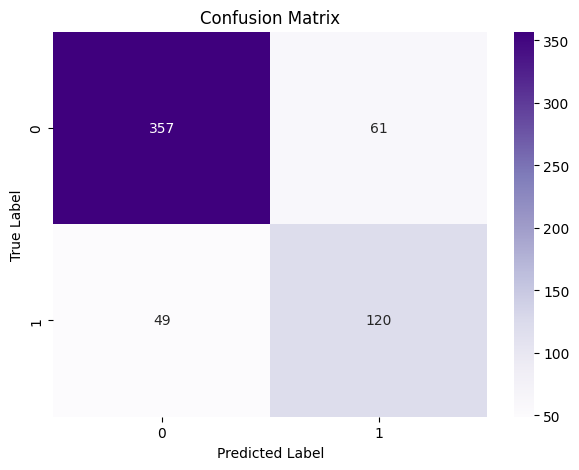

In [6]:
def build_bow_binary(docs: list, vocab: list, word_index: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. 1 means that the word is present in the
    document and 0 means that the word is not present in the document. The matrix can be normalized by the L2 norm of
    the rows.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.

    Returns
    -------
    np.ndarray
        Bag of words matrix with binary weights.
    """
    # Create the bag of words matrix.
    bow = np.zeros((len(docs), len(vocab)), dtype = float) # Create a matrix of zeros.
    for i, doc in enumerate(docs):                         # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))     # Tokenize the document.
        for word in word_counts:                           # Iterate over the words.
            if word in word_index:                         # If the word is in the vocabulary.
                bow[i, word_index[word]] = 1               # Set the corresponding entry to 1.

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(bow, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                  # Avoid division by zero.
        bow /= norms                                           # Normalize the rows.

    return bow

# Train a linear SVM with binary weights.
print(70*"-")
print("SVM with binary weights:")
print(70*"-")
SVM_classification(build_BoW = build_bow_binary)

### **2.2.- Evalúe BoW con pesado frecuencia.**

> Se define la función *build_bow_frequency()* la cual contruye la matriz de bolsa de palabras usando un pesado de frecuencia de los términos, reflejando la frecuencia de palabras en lugar de solo presencia. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with frequency weights:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88       418
           1       0.68      0.76      0.72       169

    accuracy                           0.83       587
   macro avg       0.79      0.81      0.80       587
weighted avg       0.84      0.83      0.83       587


Number of incorrect predictions: 101



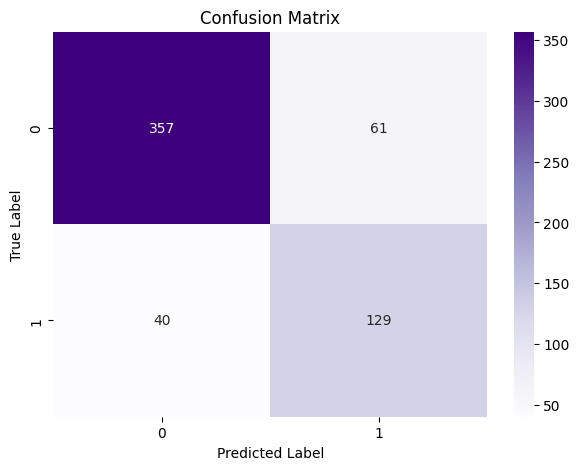

In [7]:
def build_bow_frequency(docs: list, vocab: list, word_index: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. The weights are the frequency of the words in
    the documents. The matrix can be normalized by the L2 norm of the rows.

    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.
    
    Returns
    -------
    np.ndarray
        Bag of words matrix with frequency weights.
    """
    bow = np.zeros((len(docs), len(vocab)), dtype = float)     # Create a matrix of zeros.
    for i, doc in enumerate(docs):                             # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))         # Count the words in the document.
        total_words = sum(word_counts.values())                # Total number of words in the document.
        for word, count in word_counts.items():                # Iterate over the words.
            if word in word_index:                             # If the word is in the vocabulary.            
                bow[i, word_index[word]] = count / total_words # Frequency of the word in the doc.

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(bow, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                  # Avoid division by zero.
        bow /= norms                                           # Normalize the rows.

    return bow

# Train a linear SVM with frequency weights.
print(70*"-")
print("SVM with frequency weights:")
print(70*"-")
SVM_classification(build_BoW = build_bow_frequency)

### **2.3.- Evalúe BoW con pesado tfidf.**

> Se define la función *build_bow_tfidf()* la cual contruye la matriz de bolsa de palabras usando un pesado TF-IDF de los términos. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with TF-IDF weights:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       418
           1       0.70      0.76      0.73       169

    accuracy                           0.84       587
   macro avg       0.80      0.81      0.81       587
weighted avg       0.84      0.84      0.84       587


Number of incorrect predictions: 96



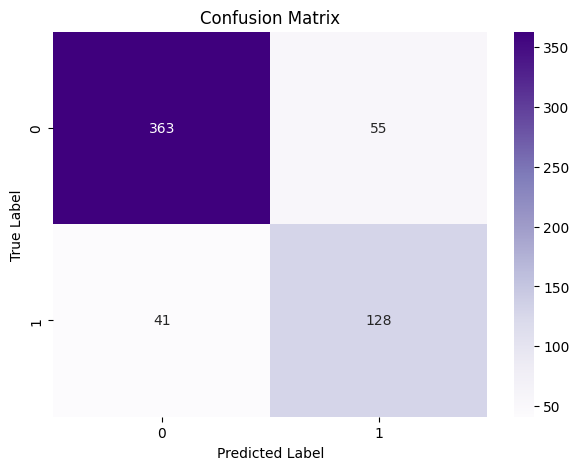

In [8]:
def build_bow_tfidf(docs: list, vocab: list, word_index: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a bag of words matrix. Rows are documents and columns are words. The weights are the TF-IDF values of the words
    in the documents. The matrix can be normalized by the L2 norm of the rows.
    
    Parameters
    ----------
    docs : list
        List of documents.
    vocab : list
        List of words.
    word_index : dict
        Dictionary with the indices of the words.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.

    Returns
    -------
    np.ndarray
        Bag of words matrix with TF-IDF weights.
    """
    N = len(docs)                                           # Number of documents.
    df = np.zeros(len(vocab), dtype = float)                # For calculate document frequency for each word.
    tfidf_matrix = np.zeros((N, len(vocab)), dtype = float) # For storing the TF-IDF values.

    # First, we count the number of documents that contain each word.
    for doc in docs:                          # Iterate over the documents.     
        words = set(tokenizer.tokenize(doc))  # Unique words in the document.
        for word in words:                    # Iterate over the words.
            if word in word_index:            # If the word is in the vocabulary.
                df[word_index[word]] += 1     # Increment the document frequency of the word.

    # Second, we calculate the IDF values.
    idf = np.log(N / (1 + df))                # log(N / (1 + df)) to avoid division by zero.

    # Finally, we calculate the TF-IDF values.
    for i, doc in enumerate(docs):                             # Iterate over the documents.
        word_counts = Counter(tokenizer.tokenize(doc))         # Count the words in the document.
        total_words = sum(word_counts.values())                # Total number of words in the document.
        for word, count in word_counts.items():                # Iterate over the words.
            if word in word_index:                             # If the word is in the vocabulary.
                tf = count / total_words                       # Calculate TF.
                word_idx = word_index[word]                    # Index of the word.
                tfidf_matrix[i, word_idx] = tf * idf[word_idx] # Calcular TF-IDF

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        
        norms = np.linalg.norm(tfidf_matrix, axis = 1, keepdims = True) # Calculate the L2 norm of each row.
        norms[norms == 0] = 1                                           # Avoid division by zero.
        tfidf_matrix /= norms                                           # Normalize the rows.

    return tfidf_matrix

# Train a linear SVM with TF-IDF weights.
print(70*"-")
print("SVM with TF-IDF weights:")
print(70*"-")
SVM_classification(build_BoW = build_bow_tfidf)

### **2.4.- Evalúe BoW con pesado binario normalizado l2 (no use sklearn).**

> Se define la función *build_bow_normalized_binary_l2()* a raíz de la función *build_bow_binary()* la cual contruye la matriz de bolsa de palabras usando un pesado binario de los términos aplicando normalización l2. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with binary weights and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87       418
           1       0.68      0.74      0.71       169

    accuracy                           0.82       587
   macro avg       0.78      0.80      0.79       587
weighted avg       0.83      0.82      0.83       587


Number of incorrect predictions: 104



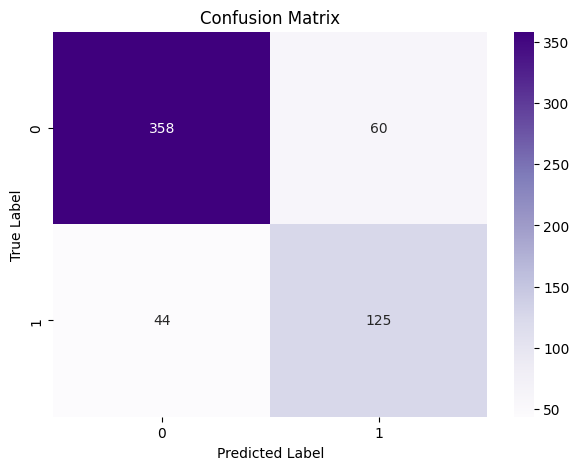

In [9]:
# We use the function build_bow_binary by setting the parameter normalized to True.
build_bow_normalized_binary_l2 = lambda docs, vocab, word_index: build_bow_binary(docs, vocab, word_index, normalized = True)

# Train a linear SVM with binary weights and L2 normalization.
print(70*"-")
print("SVM with binary weights and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_bow_normalized_binary_l2)

### **2.5.- Evalúe BoW con pesado frecuencia normalizado l2 (no use sklearn).**

> Se define la función *build_bow_normalized_frequency_l2()* a raíz de la función *build_bow_frequency()* la cual contruye la matriz de bolsa de palabras usando un pesado de frecuencia de los términos aplicando normalización l2. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with frequency weights and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       418
           1       0.69      0.78      0.73       169

    accuracy                           0.83       587
   macro avg       0.80      0.82      0.81       587
weighted avg       0.84      0.83      0.84       587


Number of incorrect predictions: 97



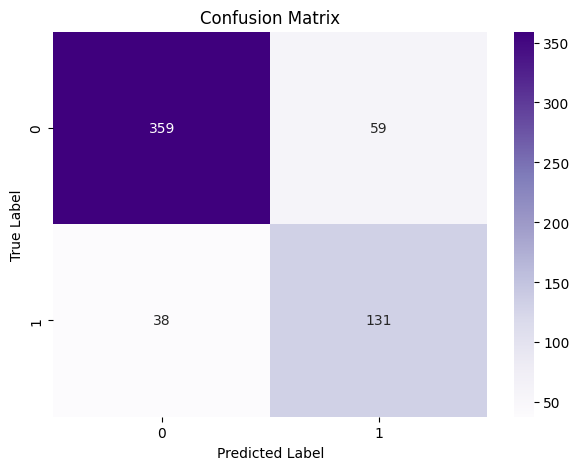

In [10]:
# We use the function build_bow_frequency by setting the parameter normalized to True.
build_bow_normalized_frequency_l2 = lambda docs, vocab, word_index: build_bow_frequency(docs, vocab, word_index, normalized = True)

# Train a linear SVM with frequency weights and L2 normalization.
print(70*"-")
print("SVM with frequency weights and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_bow_normalized_frequency_l2)

### **2.6.- Evalúe BoW con pesado tfidf normalizado l2 (no use sklearn).**

> Se define la función *build_bow_normalized_tfidf_l2()* a raíz de la función *build_bow_tfidf()* la cual contruye la matriz de bolsa de palabras usando un pesado TF-IDF de los términos aplicando normalización l2. Se hace la clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with TF-IDF weights and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87       418
           1       0.66      0.75      0.70       169

    accuracy                           0.82       587
   macro avg       0.78      0.80      0.79       587
weighted avg       0.83      0.82      0.82       587


Number of incorrect predictions: 107



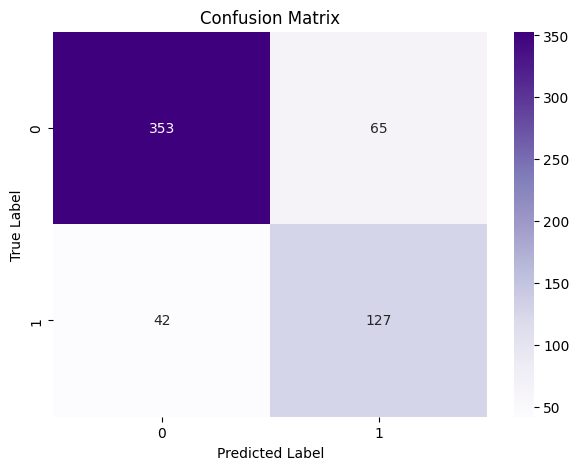

In [11]:
# We use the function build_bow_tfidf by setting the parameter normalized to True.
build_bow_normalized_tfidf_l2 = lambda docs, vocab, word_index: build_bow_tfidf(docs, vocab, word_index, normalized = True)

# Train a linear SVM with TF-IDF weights and L2 normalization.
print(70*"-")
print("SVM with TF-IDF weights and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_bow_normalized_tfidf_l2)

### **2.7.- Ponga una tabla comparativa a modo de resumen con las seis entradas anteriores.**

| Method                                | Precision (macro avg) | Recall (macro avg) | F1-score (macro avg) | Accuracy | Errors |
|----------------------------------------|----------------------|--------------------|---------------------|----------|---------|
| **BoW Binary**                        | 0.77                 | 0.78               | 0.78                | 0.81     | 110     |
| **BoW Frequency**                     | 0.79                 | 0.81               | 0.80                | 0.83     | 101     |
| **BoW TF-IDF**                         | 0.80                 | 0.81               | 0.81                | 0.84     | 96      |
| **BoW Binary + L2**                   | 0.78                 | 0.80               | 0.79                | 0.82     | 104     |
| **BoW Frequency + L2**                | 0.80                 | 0.82               | 0.81                | 0.83     | 97      |
| **BoW TF-IDF + L2**                    | 0.78                 | 0.80               | 0.79                | 0.82     | 107     |

### **2.8.- De las configuraciones anteriores elija la mejor y evalúela con más y menos términos (e.g., 1000 y 7000). Ponga una tabla dónde compare tres configuraciones distintas.**

> La bolsa de palabras con pesado de términos **TF-IDF** resultó ser la mejor, aunque por poca diferencia sobre la que tiene pesado por frecuencia y con normalización l2.
>
> Dado esto, se toman más y menos términos (7000 y 1000 respectivamente) y se repitió el proceso de clasificación SVM usando la función *SVM_classification()*.

----------------------------------------------------------------------
SVM with TF-IDF weights for 7000 words:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88       418
           1       0.68      0.76      0.72       169

    accuracy                           0.83       587
   macro avg       0.79      0.81      0.80       587
weighted avg       0.83      0.83      0.83       587


Number of incorrect predictions: 102



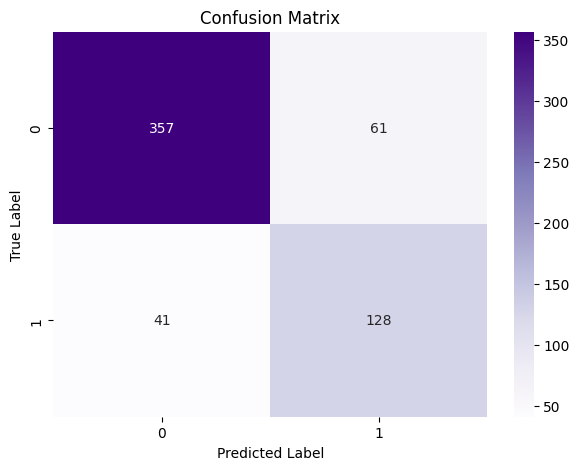

In [12]:
top_words7000 = [word for word, _ in fdist.most_common(7000)]        # Select the 7000 most frequent words.
dict_indices7000 = {word: i for i, word in enumerate(top_words7000)} # Create a dictionary with the indices of the words.
#print(top_words7000)
#dict_indices7000

print(70*"-")
print("SVM with TF-IDF weights for 7000 words:")
print(70*"-")

SVM_classification(build_BoW = build_bow_tfidf, top_words = top_words7000, dict_indices = dict_indices7000)

----------------------------------------------------------------------
SVM with TF-IDF weights for 1000 words:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86       418
           1       0.65      0.74      0.69       169

    accuracy                           0.81       587
   macro avg       0.77      0.79      0.78       587
weighted avg       0.82      0.81      0.82       587


Number of incorrect predictions: 110



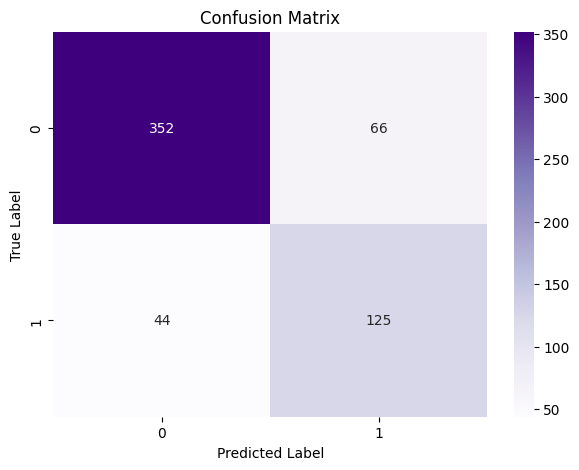

In [13]:
top_words1000 = [word for word, _ in fdist.most_common(1000)]        # Select the 1000 most frequent words.
dict_indices1000 = {word: i for i, word in enumerate(top_words1000)} # Create a dictionary with the indices of the words.
#print(top_words1000)
#dict_indices1000

print(70*"-")
print("SVM with TF-IDF weights for 1000 words:")
print(70*"-")
SVM_classification(build_BoW = build_bow_tfidf, top_words = top_words1000, dict_indices = dict_indices1000)

| Vocabulary Size     | Precision (macro avg)| Recall (macro avg) | F1-score (macro avg)| Accuracy | Errors |
|---------------------|----------------------|--------------------|---------------------|----------|--------|
| **1000 words**      | 0.77                 | 0.79               | 0.78                | 0.81     | 110    |
| **5000 words**      | 0.80                 | 0.81               | 0.81                | 0.84     | 96     |
| **7000 words**      | 0.79                 | 0.81               | 0.80                | 0.83     | 102    |

> 1. El modelo con 5000 palabras obtuvo el mejor rendimiento global, con:
>    - Mayor precisión (0.80)
>    - Mayor F1-score (0.81)
>    - Mayor accuracy (84%)
>    - Menor número de errores (96)
>	2.	Reducir el vocabulario a 1000 palabras disminuyó el rendimiento, lo que indica que se pierde información importante.
>	3.	Aumentar el vocabulario a 7000 palabras no mejoró e incluso genera más errores (102). Esto sugiere que agregar palabras menos frecuentes puede introducir más ruido.

### **2.9.- Utilice el recurso léxico del Consejo Nacional de Investigación de Canadá llamado "EmoLex" (https://www.saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm) para construir una "Bolsa de Emociones" de los Tweets de agresividad (Debe usar EmoLex en Español). Para esto, una estrategia sencilla sería enmascarar (sustituir) cada palabra con su emoción, y después construir la Bolsa de Emociones (BoE).**

> Se asume que el archivo *Spanish-NRC-EmoLex.txt*, en el que se encuentran los datos de EmoLex en español, se encuentra en el directorio './data/'. Se cargan los datos usando la librería Pandas y se renombran las columnas para un fácil manejo.

In [14]:
# Charge the file.
emolex_df = pd.read_csv("./data/Spanish-NRC-EmoLex.txt", sep = "\t") 

# Rename the columns.
emolex_df.columns = ["english", "anger", "anticipation", "disgust", "fear", "joy",
                     "negative", "positive", "sadness", "surprise", "trust", "spanish"]

# Display the first rows of the dataframe.
emolex_df.head()

,english,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,spanish
0,aback,0,0,0,0,0,0,0,0,0,0,detrás
1,abacus,0,0,0,0,0,0,0,0,0,1,ábaco
2,abandon,0,0,0,1,0,1,0,1,0,0,abandonar
3,abandoned,1,0,0,1,0,1,0,1,0,0,abandonado
4,abandonment,1,0,0,1,0,1,0,1,1,0,abandono


> Dado esto, se crea el diccionario que mapea palabras en español a sus emotiociones recorriendo el frame de datos en búsqueda de los sentimientos que tengan "1". El número de palabras resultante fue 5410.

In [15]:
# List of emotions in EmoLex.
emotions = ["anger", "anticipation", "disgust", "fear", "joy", "negative", "positive", "sadness", "surprise", "trust"]

# Create a dictionary with the words and the emotions in EmoLex.
emolex_dict = {}                                                            # Dictionary with the words and the emotions.
for _, row in emolex_df.iterrows():                                         # Iterate over the rows.
    word = row["spanish"].strip().lower()                                   # Word in lowercase.
    list_emotions = [emotion for emotion in emotions if row[emotion] == 1]  # List of emotions.
    if list_emotions:                                                       # If there are emotions.
        emolex_dict[word] = list_emotions                                   # Add the word and the emotions to the dictionary.

# Number of words in EmoLex.
print("Number of words in EmoLex:", len(emolex_dict))
print("Dictionary:", emolex_dict)

Number of words in EmoLex: 5410
Dictionary: {'ábaco': ['trust'], 'abandonar': ['negative'], 'abandonado': ['anger', 'negative', 'sadness'], 'abandono': ['anger', 'fear', 'negative', 'sadness', 'surprise'], 'abba': ['positive'], 'abad': ['trust'], 'secuestro': ['negative', 'sadness'], 'aberrante': ['negative'], 'aberración': ['disgust', 'negative'], 'aborrecer': ['anger', 'disgust', 'fear', 'negative'], 'aborrecible': ['anger', 'disgust', 'fear', 'negative'], 'capacidad': ['positive'], 'abyecto': ['disgust', 'negative'], 'anormal': ['disgust', 'negative'], 'abolir': ['anger', 'negative'], 'abolición': ['negative'], 'abominable': ['disgust', 'fear', 'negative'], 'abominación': ['anger', 'disgust', 'fear', 'negative'], 'abortar': ['negative'], 'aborto': ['disgust', 'fear', 'negative', 'sadness'], 'abortivo': ['negative', 'sadness'], 'anteriormente mencionado': ['positive'], 'abrasión': ['negative'], 'abrogar': ['negative'], 'abrupto': ['surprise'], 'absceso': ['negative', 'sadness'], 'aus

>**NOTA IMPORTANTE:** No entendí muy bien si
> 1. había que hacer únicamente una Bolsa de Emociones con algún pesado y esto compararlo con las tres variantes de BoW que se tienen anteriormente en tabla comparativa que se pide en el **2.1**. O bien,
> 2. hacer tres versiones de BoE con los tres diferentes pesos usados.
>
>Así que decidí crear las tres variantes de BoE.
> A continuación, se crean las funciones
> - *build_BoE_binary()*
> - *build_BoE_frequency()*
> - *build_BoE_tfidf()*
>
>Las cuales construyen la matriz de bolsa según el pesado correspondiente. Dentro de estas funciones se decide si se quiere aplicar la normalización l2 o no. (A última hora se me ocurrió hacer una sola función que pudiera hacer las tres configuraciones pero no alcancé a terminarla, así que me quedé con las versiones separadas.)

In [16]:
def build_BoE_binary(docs: list, emotions: list, emolex: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using binary weights. Rows are docs and columns are emotions.
    The values are 1 if the emotion appears in the doc, 0 otherwise.

    Parameters
    ----------
    docs : list
        List of docs.
    emotions : list
        List of emotions.
    emolex : dict
        Dictionary with the words and the emotions in EmoLex.

    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with binary weights.
    """
    boe_matrix = np.zeros((len(docs), len(emotions)), dtype=float)  # Create a matrix of zeros.

    for i, doc in enumerate(docs):                   # Iterate over the docs.
        tokens = tokenizer.tokenize(doc.lower())     # Tokenize the doc and convert words to lowercase.
        emotion_counts = Counter()                   # Create a counter for emotions.

        for token in tokens:                         # Iterate over the tokens.
            if token in emolex:                      # If the token is in the dictionary.
                emotion_counts.update(emolex[token]) # Update the counter with the emotions.

        for j, emotion in enumerate(emotions):
            boe_matrix[i,j] = 1 if emotion_counts[emotion] > 0 else 0  # Binary presence

    if normalized: # Normalize the rows of the matrix by their L2 norm.
        norms = np.linalg.norm(boe_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        boe_matrix /= norms

    return boe_matrix

def build_BoE_frequency(docs: list, emotions: list, emolex: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using frequency weights. Rows are docs and columns are emotions.
    The values represent the frequency of each emotion in the document.

    Parameters
    ----------
    docs : list
        List of docs.
    emotions : list
        List of emotions.
    emolex : dict
        Dictionary with the words and the emotions in EmoLex.

    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with frequency weights.
    """
    boe_matrix = np.zeros((len(docs), len(emotions)), dtype = float) # Create a matrix of zeros.

    for i, doc in enumerate(docs):                    # Iterate over the docs.
        tokens = tokenizer.tokenize(doc.lower())      # Tokenize the doc and convert words to lowercase.
        emotion_counts = Counter()                    # Create a counter for emotions.

        for token in tokens:                          # Iterate over the tokens.
            if token in emolex:                       # If the token is in the dictionary.
                emotion_counts.update(emolex[token])  # Update the counter with the emotions.

        total_emotions = sum(emotion_counts.values()) # Total number of emotions in the doc
        for j, emotion in enumerate(emotions):
            boe_matrix[i, j] = emotion_counts[emotion] / total_emotions if total_emotions > 0 else 0

    if normalized:  # Normalize the rows of the matrix by their L2 norm.
        norms = np.linalg.norm(boe_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        boe_matrix /= norms

    return boe_matrix

def build_BoE_tfidf(docs: list, emotions: list, emolex: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using TF-IDF weights. Rows are docs and columns are emotions.
    The values represent the term frequency-inverse document frequency of each emotion in the document.

    Parameters
    ----------
    docs : list
        List of docs.
    emotions : list
        List of emotions.
    emolex : dict
        Dictionary with the words and the emotions in EmoLex.

    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with TF-IDF weights.
    """
    N = len(docs)
    boe_matrix = np.zeros((N, len(emotions)), dtype = float)

    doc_count = Counter()     # Count how many docs contain each emotion
    tweet_emotion_counts = [] # Count the emotions in each tweet

    # First pass: count emotions per tweet and doc frequency
    for doc in docs:
        tokens = tokenizer.tokenize(doc.lower())
        emotion_counts = Counter()

        for token in tokens:
            if token in emolex:
                emotion_counts.update(emolex[token])

        tweet_emotion_counts.append(emotion_counts)

        for emotion in set(emotion_counts.keys()):
            doc_count[emotion] += 1

    # Second pass: fill the matrix with TF-IDF values
    for i, emotion_counts in enumerate(tweet_emotion_counts):
        total_emotions = sum(emotion_counts.values())

        for j, emotion in enumerate(emotions):
            tf = emotion_counts[emotion] / total_emotions if total_emotions > 0 else 0
            idf = np.log(N / (doc_count[emotion] + 1))  # Avoid division by zero
            boe_matrix[i, j] = tf * idf

    if normalized:  # Normalize the rows of the matrix by their L2 norm.
        norms = np.linalg.norm(boe_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        boe_matrix /= norms

    return boe_matrix

### **2.10.- Usa tú BoE de alguna forma y clasifica con SVM. Ponga una tabla comparativa a modo de resumen con tres pesados (bin, tf, tfidf), normalize cada uno si lo cree conveniente.**

> Se hace la clasificación SVM con los mismos hiperparámetros que antes para la bolsa de emociones con y sin normalización usando la función *SVM_classification()* para los 6 casos de BoE (los tres pesados con y sin normalización).
>
>**NOTA:** Notemos que tenemos que cambiar top_words por emotions y dict_indices por emolex_dict ya que ahora estamos trabajando con los valores de las emociones.

----------------------------------------------------------------------
SVM with BoE (Binary Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       418
           1       0.42      0.33      0.37       169

    accuracy                           0.67       587
   macro avg       0.58      0.57      0.57       587
weighted avg       0.65      0.67      0.66       587


Number of incorrect predictions: 191



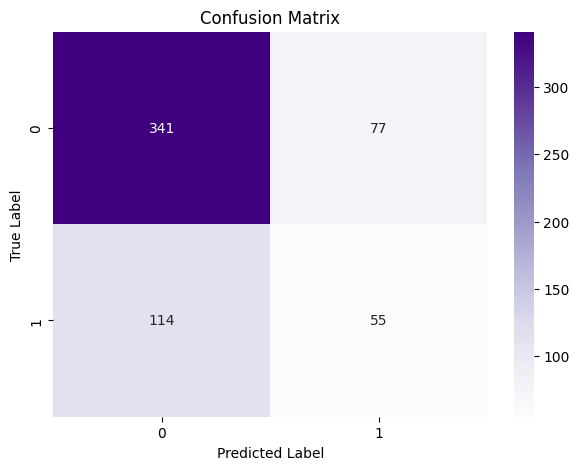

----------------------------------------------------------------------
SVM with BoE (Binary Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       418
           1       0.42      0.34      0.37       169

    accuracy                           0.67       587
   macro avg       0.59      0.57      0.58       587
weighted avg       0.66      0.67      0.66       587


Number of incorrect predictions: 191



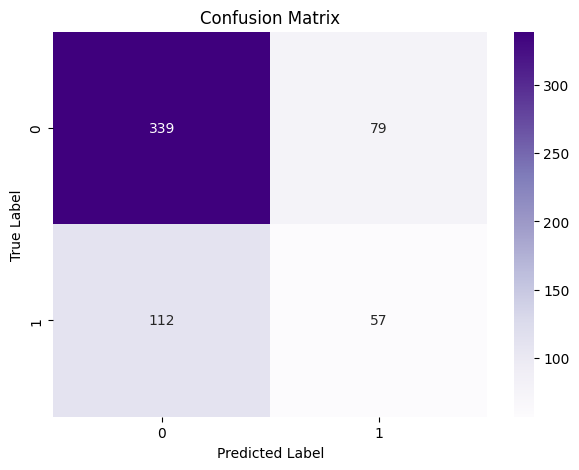

In [17]:
print(70*"-")
print("SVM with BoE (Binary Weights):")
print(70*"-")
SVM_classification(build_BoW = build_BoE_binary, top_words = emotions, dict_indices = emolex_dict)

# We use the function build_BoE_binary by setting the parameter normalized to True.
build_BoE_normalized_binary_l2 = lambda docs, vocab, word_index: build_BoE_binary(docs, vocab, word_index, normalized = True)

print(70*"-")
print("SVM with BoE (Binary Weights) and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_BoE_normalized_binary_l2, top_words = emotions, dict_indices = emolex_dict)

----------------------------------------------------------------------
SVM with BoE (Frequency Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77       418
           1       0.39      0.34      0.37       169

    accuracy                           0.66       587
   macro avg       0.57      0.57      0.57       587
weighted avg       0.65      0.66      0.65       587


Number of incorrect predictions: 200



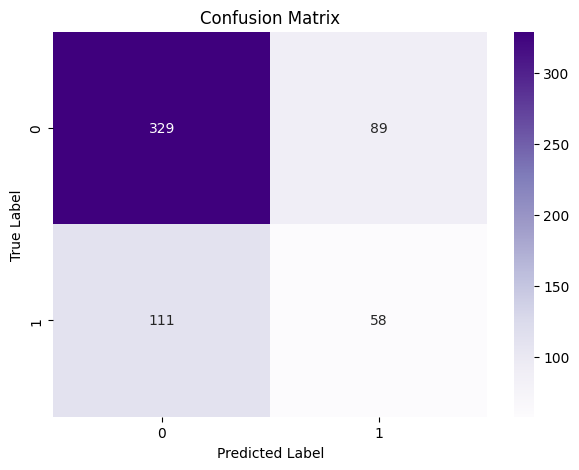

----------------------------------------------------------------------
SVM with BoE (Frequency Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.82      0.78       418
           1       0.40      0.31      0.35       169

    accuracy                           0.67       587
   macro avg       0.57      0.56      0.56       587
weighted avg       0.65      0.67      0.65       587


Number of incorrect predictions: 194



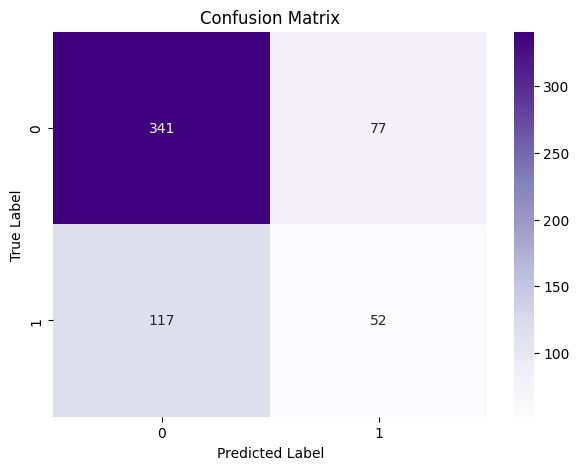

In [18]:
print(70*"-")
print("SVM with BoE (Frequency Weights):")
print(70*"-")
SVM_classification(build_BoW = build_BoE_frequency, top_words = emotions, dict_indices = emolex_dict)

# We use the function build_BoE_frequency by setting the parameter normalized to True.
build_BoE_normalized_frequency_l2 = lambda docs, vocab, word_index: build_BoE_frequency(docs, vocab, word_index, normalized = True)

print(70*"-")
print("SVM with BoE (Frequency Weights) and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_BoE_normalized_frequency_l2, top_words = emotions, dict_indices = emolex_dict)

----------------------------------------------------------------------
SVM with BoE (TF-IDF Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.78      0.77       418
           1       0.39      0.34      0.37       169

    accuracy                           0.66       587
   macro avg       0.57      0.56      0.57       587
weighted avg       0.64      0.66      0.65       587


Number of incorrect predictions: 201



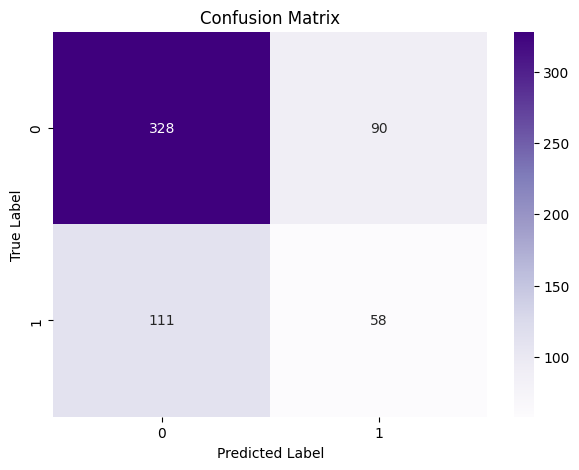

----------------------------------------------------------------------
SVM with BoE (TF-IDF Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       418
           1       0.41      0.32      0.36       169

    accuracy                           0.67       587
   macro avg       0.58      0.57      0.57       587
weighted avg       0.65      0.67      0.66       587


Number of incorrect predictions: 194



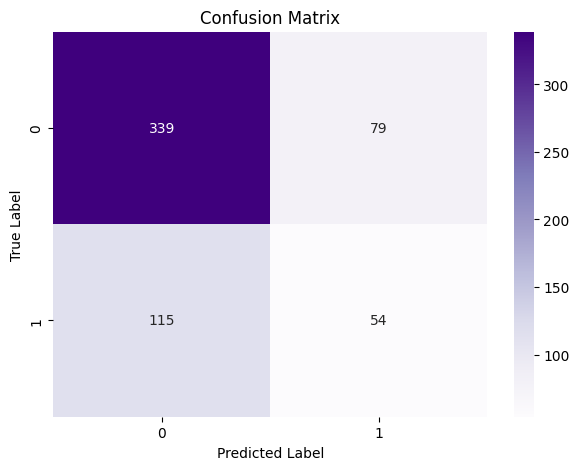

In [19]:
print(70*"-")
print("SVM with BoE (TF-IDF Weights):")
print(70*"-")
SVM_classification(build_BoW = build_BoE_tfidf, top_words = emotions, dict_indices = emolex_dict)

# We use the function build_BoE_tfidf by setting the parameter normalized to True.
build_BoE_normalized_tfidf_l2 = lambda docs, vocab, word_index: build_BoE_tfidf(docs, vocab, word_index, normalized = True)

print(70*"-")
print("SVM with BoE (TF-IDF Weights) and L2 normalization:")
print(70*"-")
SVM_classification(build_BoW = build_BoE_normalized_tfidf_l2, top_words = emotions, dict_indices = emolex_dict)

| Weight                | Precision | Recall | F1-score | Accuracy | Errors |
|--------------------------------|-----------|--------|----------|----------|-----------------------|
| **BoE Binary**                 | 0.58      | 0.57   | 0.57     | 0.67     | 191                   |
| **BoE Binary + L2**            | 0.59      | 0.57   | 0.58     | 0.67     | 191                   |
| **BoE Frequency**              | 0.57      | 0.57   | 0.57     | 0.66     | 200                   |
| **BoE Frequency + L2**         | 0.57      | 0.56   | 0.56     | 0.67     | 194                   |
| **BoE TF-IDF**                 | 0.57      | 0.56   | 0.57     | 0.66     | 201                   |
| **BoE TF-IDF + L2**            | 0.58      | 0.57   | 0.57     | 0.67     | 194                   |

* * *
# **3.- Recurso Línguistico de Emociones Mexicano (30 pts)**

### **3.1.- Utilice el recurso léxico llamado "Spanish Emotion Lexicon (SEL)" del Dr. Grigori Sidorov, profesor del Centro de Investigación en Computación (CIC) del Instituto Politécnico Nacional (http://www.cic.ipn.mx/∼sidorov/), para enmascarar cada palabra con su emoción, y después construir la Bolsa de Emociones con algún pesado (e.g., binario, tf, tfidf). Proponga alguna estrategia para incorporar el "valor" del "Probability Factor of Affective use" en su representación vectorial del documento. Evalúa y escribe una tabla comparativa a modo de resumen con al menos tres pesados: binario, frecuencia, tfidf. Normalize cada pesado según lo crea conveniente.**

> Se asume que el archivo *SEL.txt*, en el que se encuentran los datos Spanish Emotion Lexicon, se encuentra en el directorio './data/'. Se cargan los datos usando la librería Pandas y se renombran las columnas para un fácil manejo.

In [20]:
# Charge the file.
sel_df = pd.read_csv("./data/SEL.txt", sep = "\t", encoding = "latin1")

# Rename the columns.
sel_df.columns = ["word", "PFA", "emotion"]

# Convert to lowercase for consistency
sel_df["word"] = sel_df["word"].str.lower()
sel_df["emotion"] = sel_df["emotion"].str.lower()

# Display the first rows of the dataframe.
sel_df.head()

,word,PFA,emotion
0,abundancia,0.830,alegría
1,acabalar,0.396,alegría
2,acallar,0.198,alegría
3,acatar,0.198,alegría
4,acción,0.397,alegría


> Dado esto, se crea el diccionario donde cada palabra corresponde a (emoción, PFA). Se comenta más de esto al final del ejercicio a modo de conclusiones.

In [21]:
# Create the dictionary where each word maps to (emotion, PFA)
sel_dict = {}
for _, row in sel_df.iterrows():
    word = row["word"]
    emotion = row["emotion"]
    pfa = row["PFA"]
    
    if word not in sel_dict:
        sel_dict[word] = []
    sel_dict[word].append((emotion, pfa))

emotions_list = sel_df["emotion"].unique().tolist()  # Unique emotion categories

# Number of words in SEL.
print("Number of tokens in SEL:", len(sel_dict))
print("Dictionary:", sel_dict)

Number of tokens in SEL: 1909
Dictionary: {'abundancia': [('alegría', 0.83)], 'acabalar': [('alegría', 0.396)], 'acallar': [('alegría', 0.198)], 'acatar': [('alegría', 0.198)], 'acción': [('alegría', 0.397)], 'aceptable': [('alegría', 0.594)], 'aceptación': [('alegría', 0.696)], 'acicate': [('alegría', 0.429)], 'aclamación': [('alegría', 0.799)], 'aclamar': [('alegría', 0.799)], 'acogedor': [('alegría', 0.83)], 'acoger': [('alegría', 0.729)], 'acomodadamente': [('alegría', 0.729)], 'acuciar': [('alegría', 0.264)], 'acucioso': [('alegría', 0.232)], 'adecuar': [('alegría', 0.331)], 'adicto': [('alegría', 0.429)], 'admirable': [('alegría', 0.764), ('sorpresa', 0.73)], 'admirablemente': [('alegría', 0.765), ('sorpresa', 0.663)], 'admiración': [('alegría', 0.765), ('sorpresa', 0.764)], 'admirar': [('alegría', 0.731), ('sorpresa', 0.73)], 'admitir': [('alegría', 0.53)], 'adorable': [('alegría', 0.898)], 'adorablemente': [('alegría', 0.865)], 'adoración': [('alegría', 0.765)], 'adorador': [('

> Se implementan tres funciones:
> - *build_BoE_binarySEL()*
> - *build_BoE_frequency_SEL()*
> - *build_BoE_tfidf()_SEL*
> Las cuales construyen la matriz de bolsa según el pesado correspondiente. Dentro de estas funciones se decide si se quiere aplicar la normalización l2 o no. 

In [22]:
def build_BoE_binary_SEL(docs: list, sel_dict: dict, emotions_list: list, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using binary weights. Rows are docs and columns are emotions. The values are 1
    if the emotion appears in the doc, 0 otherwise. The emotions are extracted from the SEL dictionary.
    
    Parameters
    ----------
    docs : list
        List of docs.
    sel_dict : dict
        Dictionary with the words and the emotions in SEL.
    emotions_list : list
        List of emotions.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.
        
    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with binary weights.
    """
    boe_matrix = np.zeros((len(docs), len(emotions_list)), dtype = float)

    for i, doc in enumerate(docs):
        tokens = set(tokenizer.tokenize(doc.lower())) 
        emotion_counts = Counter()

        for token in tokens:
            if token in sel_dict:
                for emotion, pfa in sel_dict[token]:  
                    emotion_counts[emotion] = 1  

        for j, emotion in enumerate(emotions_list):
            boe_matrix[i, j] = emotion_counts[emotion]

    if normalized:
        norms = np.linalg.norm(boe_matrix, axis = 1, keepdims = True)
        norms[norms == 0] = 1
        boe_matrix /= norms

    return boe_matrix

def build_BoE_frequency_SEL(docs: list, sel_dict: dict, emotions_list: list, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using frequency weights. Rows are docs and columns are emotions. The values
    represent the frequency of each emotion in the document. The emotions are extracted from the SEL dictionary.
    
    Parameters
    ----------
    docs : list
        List of docs.
    sel_dict : dict
        Dictionary with the words and the emotions in SEL.
    emotions_list : list
        List of emotions.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.
        
    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with frequency weights.
    """
    boe_matrix = np.zeros((len(docs), len(emotions_list)), dtype = float)

    for i, doc in enumerate(docs):
        tokens = tokenizer.tokenize(doc.lower())
        emotion_counts = Counter()

        for token in tokens:
            if token in sel_dict:
                for emotion, pfa in sel_dict[token]:  
                    emotion_counts[emotion] += pfa  # Frequency weighted by PFA

        total_words = len(tokens) if len(tokens) > 0 else 1  # Avoid division by zero
        for j, emotion in enumerate(emotions_list):
            boe_matrix[i, j] = emotion_counts[emotion] / total_words

    if normalized:
        norms = np.linalg.norm(boe_matrix, axis = 1, keepdims = True)
        norms[norms == 0] = 1
        boe_matrix /= norms

    return boe_matrix

def build_BoE_tfidf_SEL(docs: list, sel_dict: dict, emotions_list: list, normalized: bool = False) -> np.ndarray:
    """
    Build a Bag of Emotions (BoE) matrix using TF-IDF weights. Rows are docs and columns are emotions. The values
    represent the term frequency-inverse document frequency of each emotion in the document. The emotions are extracted
    from the SEL dictionary.

    Parameters
    ----------
    docs : list
        List of docs.
    sel_dict : dict
        Dictionary with the words and the emotions in SEL.
    emotions_list : list
        List of emotions.
    normalized : bool
        If True, normalize the rows of the matrix by their L2 norm.

    Returns
    -------
    np.ndarray
        Bag of Emotions matrix with TF-IDF weights.
    """
    N = len(docs)
    num_emotions = len(emotions_list)
    boe_matrix = np.zeros((N, num_emotions), dtype=float)
    
    doc_count = Counter()     # Tracks how many docs contain each emotion
    tweet_emotion_counts = [] # Counts the emotions in each tweet

    # First pass: Count emotions per tweet & document frequency
    for doc in docs:
        tokens = tokenizer.tokenize(doc.lower())
        emotion_counts = Counter()

        for token in tokens:
            if token in sel_dict:
                for emotion, pfa in sel_dict[token]:
                    emotion_counts[emotion] += pfa  # Use Probability Factor of Affective use (PFA)

        tweet_emotion_counts.append(emotion_counts)

        # Count documents that contain each emotion (for IDF)
        for emotion in set(emotion_counts.keys()):
            doc_count[emotion] += 1

    # Second pass: Compute TF-IDF values
    for i, emotion_counts in enumerate(tweet_emotion_counts):
        total_emotions = sum(emotion_counts.values()) if sum(emotion_counts.values()) > 0 else 1  # Avoid zero division

        for j, emotion in enumerate(emotions_list):
            tf = emotion_counts[emotion] / total_emotions    # Term Frequency
            idf = np.log((N + 1) / (doc_count[emotion] + 1)) # Inverse Document Frequency
            boe_matrix[i, j] = tf * idf                      # TF-IDF Weight

    if normalized:  # Normalize the matrix using L2 norm
        norms = np.linalg.norm(boe_matrix, axis = 1, keepdims = True)
        norms[norms == 0] = 1 
        boe_matrix /= norms

    return boe_matrix

> Se implementan además la función
> - *SVM_classification_BoE()*
> La cual tiene la misma labor de la función SVM_classification de la parte de BoWs la cual resume una clasificación SVM como en la **práctica 3**, toma como argumento principal a la función que genera la BoE con el pesado correspondiente, además de los objetos generados anteriormente como los datos y etiquetas de entrenamiento, las palabras más comunes y sus índices, así como parámetros auxiliares del clasificador (se usaron los mismos para mejor comparación). La función regresa el reporte de clasificación, el número de predicciones incorrectas y la matriz de confusión.

In [23]:
def SVM_classification_BoE(build_BoE: Callable, data_tr: list = data_tr, labels_tr: list = labels_tr, data_val: list = data_val,
                           labels_val: list = labels_val, sel_dict: dict = sel_dict, emotions_list: list = emotions_list,
                           param_grid: dict = param_grid, scoring: str = scoring, cv: int = cv) -> None:
    """
    Train and evaluate an SVM model using a Bag of Emotions (BoE) representation.

    Parameters
    ----------
    build_BoE : Callable
        Function to build the BoE matrix (e.g., Binary, TF, TF-IDF).
    data_tr : list
        List of training documents.
    labels_tr : list
        List of training labels.
    data_val : list
        List of validation documents.
    labels_val : list
        List of validation labels.
    sel_dict : dict
        Dictionary mapping words to emotions (from SEL).
    emotions_list : list
        List of unique emotions considered.
    param_grid : dict
        Hyperparameters to evaluate in GridSearch.
    scoring : str
        Metric to optimize in GridSearch.
    cv : int
        Number of folds in cross-validation.

    Returns
    -------
    None
        Prints classification results and shows the confusion matrix.
    """
    # Build the BoE matrices.
    BoE_tr = build_BoE(data_tr, sel_dict, emotions_list)   # Training data
    BoE_val = build_BoE(data_val, sel_dict, emotions_list) # Validation data

    # Train a linear SVM.
    svc = svm.LinearSVC(class_weight='balanced', dual=False)
    grid = GridSearchCV(estimator=svc, param_grid=param_grid, scoring=scoring, cv=cv, n_jobs=-1)

    # Train the model.
    grid.fit(BoE_tr, labels_tr)

    # Predict the labels.
    label_pred = grid.predict(BoE_val)

    # Evaluate the model.
    print("\nClassification Report:\n", metrics.classification_report(labels_val, label_pred))

    # Number of incorrect predictions.
    incorrect_indices = [i for i, (real, pred) in enumerate(zip(labels_val, label_pred)) if real != pred]
    print(f"\nNumber of incorrect predictions: {len(incorrect_indices)}\n")

    # Confusion matrix.
    cm = confusion_matrix(labels_val, label_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=set(labels_val), yticklabels=set(labels_val))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

----------------------------------------------------------------------
SVM with BoE (Binary Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.20      0.31       418
           1       0.29      0.80      0.43       169

    accuracy                           0.37       587
   macro avg       0.50      0.50      0.37       587
weighted avg       0.59      0.37      0.35       587


Number of incorrect predictions: 367



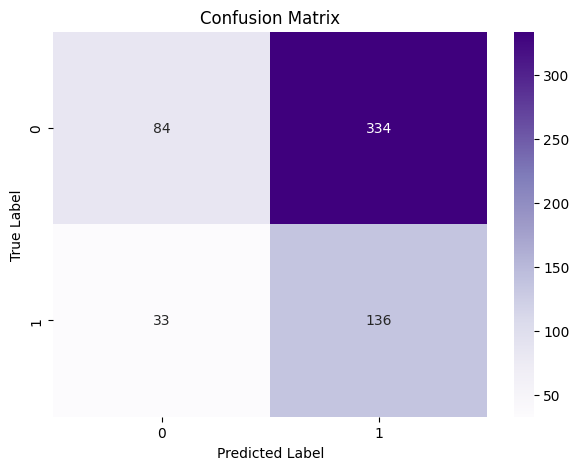

----------------------------------------------------------------------
SVM with BoE (Binary Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.20      0.31       418
           1       0.29      0.80      0.43       169

    accuracy                           0.37       587
   macro avg       0.50      0.50      0.37       587
weighted avg       0.59      0.37      0.35       587


Number of incorrect predictions: 367



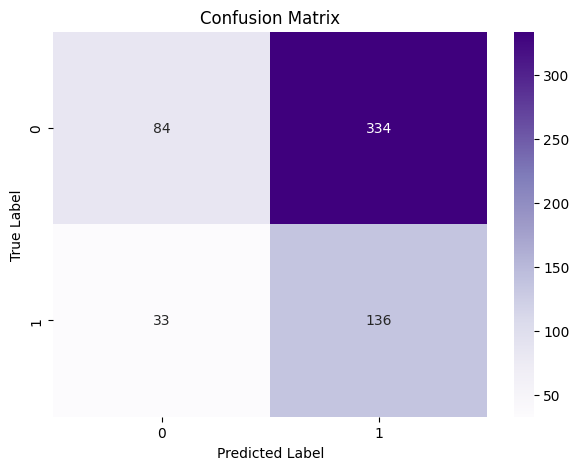

In [24]:
# Train and evaluate SVM with Binary BoE
print(70*"-")
print("SVM with BoE (Binary Weights):")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_binary_SEL)

# We use the function build_BoE_binary_SEL by setting the parameter normalized to True.
build_BoE_normalized_binary_l2_SEL = lambda docs, vocab, word_index: build_BoE_binary_SEL(docs, vocab, word_index, normalized = True)

# Train and evaluate SVM with Binary BoE and L2 normalization
print(70*"-")
print("SVM with BoE (Binary Weights) and L2 normalization:")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_normalized_binary_l2_SEL)

----------------------------------------------------------------------
SVM with BoE (Frequency Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.19      0.30       418
           1       0.29      0.83      0.43       169

    accuracy                           0.37       587
   macro avg       0.51      0.51      0.37       587
weighted avg       0.61      0.37      0.34       587


Number of incorrect predictions: 367



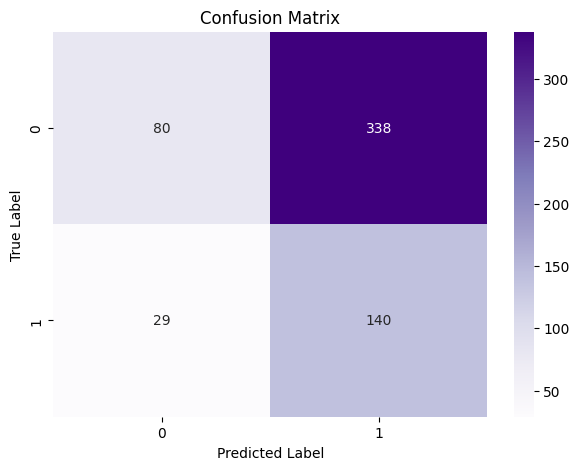

----------------------------------------------------------------------
SVM with BoE (Frequency Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.20      0.31       418
           1       0.29      0.80      0.42       169

    accuracy                           0.37       587
   macro avg       0.50      0.50      0.37       587
weighted avg       0.59      0.37      0.34       587


Number of incorrect predictions: 369



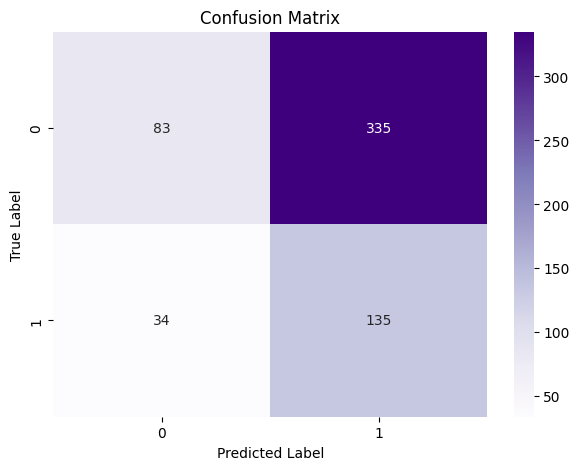

In [25]:
# Train and evaluate SVM with Frequency BoE
print(70*"-")
print("SVM with BoE (Frequency Weights):")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_frequency_SEL)

# We use the function build_BoE_frequency_SEL by setting the parameter normalized to True.
build_BoE_normalized_frequency_l2_SEL = lambda docs, vocab, word_index: build_BoE_frequency_SEL(docs, vocab, word_index, normalized = True)

# Train and evaluate SVM with Frequency BoE and L2 normalization
print(70*"-")
print("SVM with BoE (Frequency Weights) and L2 normalization:")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_normalized_frequency_l2_SEL)

----------------------------------------------------------------------
SVM with BoE (TF-IDF Weights):
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.20      0.31       418
           1       0.29      0.80      0.42       169

    accuracy                           0.37       587
   macro avg       0.50      0.50      0.37       587
weighted avg       0.59      0.37      0.34       587


Number of incorrect predictions: 369



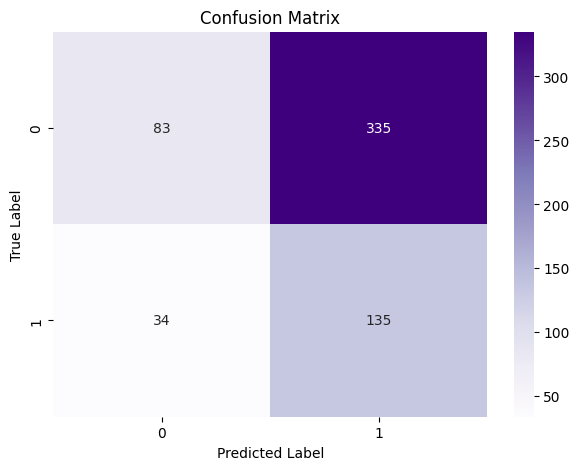

----------------------------------------------------------------------
SVM with BoE (TF-IDF Weights) and L2 normalization:
----------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.20      0.31       418
           1       0.29      0.80      0.42       169

    accuracy                           0.37       587
   macro avg       0.50      0.50      0.37       587
weighted avg       0.59      0.37      0.34       587


Number of incorrect predictions: 369



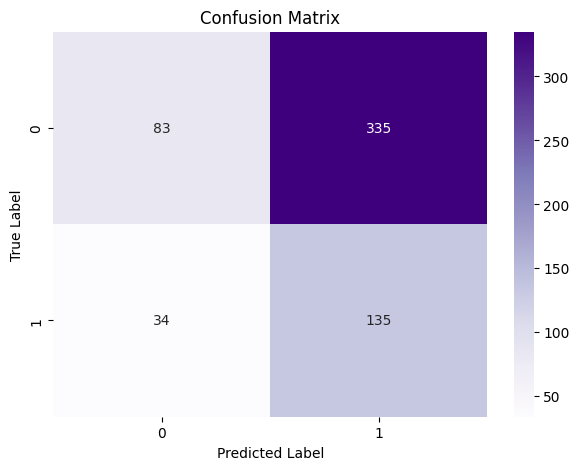

In [26]:
# Train and evaluate SVM with TF-IDF BoE
print(70*"-")
print("SVM with BoE (TF-IDF Weights):")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_tfidf_SEL)

# We use the function build_BoE_tfidf_SEL by setting the parameter normalized to True.
build_BoE_normalized_tfidf_l2_SEL = lambda docs, vocab, word_index: build_BoE_tfidf_SEL(docs, vocab, word_index, normalized = True)

# Train and evaluate SVM with TF-IDF BoE and L2 normalization
print(70*"-")
print("SVM with BoE (TF-IDF Weights) and L2 normalization:")
print(70*"-")
SVM_classification_BoE(build_BoE = build_BoE_normalized_tfidf_l2_SEL)

| Weight                | Precision (Macro Avg) | Recall (Macro Avg) | F1-score (Macro Avg) | Accuracy | Errors |
|--------------------------------|----------------------|--------------------|----------------------|----------|-----------------------|
| **BoE Binary**                 | 0.50                 | 0.50               | 0.37                 | 0.37     | 367                   |
| **BoE Binary + L2**            | 0.50                 | 0.50               | 0.37                 | 0.37     | 367                   |
| **BoE Frequency**              | 0.51                 | 0.51               | 0.37                 | 0.37     | 367                   |
| **BoE Frequency + L2**         | 0.50                 | 0.50               | 0.37                 | 0.37     | 369                   |
| **BoE TF-IDF**                 | 0.50                 | 0.50               | 0.37                 | 0.37     | 369                   |
| **BoE TF-IDF + L2**            | 0.50                 | 0.50               | 0.37                 | 0.37     | 369                   |

### **3.2.- En un comentario aparte, discuta sobre la estrategía que utilizó para incorporar el "Probability Factor of Affective use". No más de 5 renglones.**

>La estrategia usa el PFA como peso para ajustar la importancia de cada emoción en el texto. En BoE binario, el PFA se ignora, mientras que en BoE-TF y BoE-TFIDF, se suma o multiplica para reflejar la intensidad afectiva. Esto permite diferenciar mejor los textos según su carga emocional. Sin embargo, al depender de un lexicón estático, puede no capturar todas las variaciones contextuales. Esto termina notándose ya que esta parte tuvo un mal desempeño.

* * *
# **4.- ¿Podemos mejorar con Bigramas? (30 pts)**

### **4.1.- Hacer un experimento dónde concatene una buena BoW según sus experimentos anteriores con otra BoW construida a partir de los 1000 bigramas más frecuentes.**

> Según los experimentos anteriores, la mejor BoW parece ser BoW TF-IDF con 5000 palabras (F1-score = 0.81, Accuracy = 0.84, Errores = 96). Dado esto, Extraemos los 1000 bigramas más frecuentes de los datos de entrenamiento

In [27]:
# Step 1: Extract the most common 1000 bigrams
bigram_counts = Counter()
for doc in data_tr:
    tokens = tokenizer.tokenize(doc)
    bigrams = zip(tokens, tokens[1:])  # Generate bigrams
    bigram_counts.update(bigrams)

# Select the 1000 most common bigrams
top_bigrams = [bigram for bigram, _ in bigram_counts.most_common(1000)]
bigram_indices = {bigram: i for i, bigram in enumerate(top_bigrams)}

# Visualize the most common bigrams
print("Most common bigrams:", top_bigrams[:10])

Most common bigrams: [('!', '!'), ('@USUARIO', '@USUARIO'), ('a', 'la'), ('de', 'la'), ('la', 'verga'), ('que', 'no'), ('😂', '😂'), ('que', 'me'), (',', 'no'), ('en', 'la')]


> Se crea la función
>- *build_bow_bigrams()*
> La cual construye una matriz de bolsa de palabras utilizando bigramas. Cada fila representa un documento y cada columna representa un bigrama. La matriz se puede normalizar mediante la norma L2.

In [28]:
# Function to build BoW for bigrams
def build_bow_bigrams(docs: list, bigram_vocab: list, bigram_index: dict, normalized: bool = False) -> np.ndarray:
    """
    Build a bag of words matrix using bigrams. Each row represents a document, and each column represents a bigram.
    The matrix can be normalized by the L2 norm.

    Parameters
    ----------
    docs : list
        List of documents.
    bigram_vocab : list
        List of bigrams.
    bigram_index : dict
        Dictionary mapping bigrams to indices.
    normalized : bool
        If True, normalize the rows by their L2 norm.

    Returns
    -------
    np.ndarray
        Bag of words matrix with bigram frequencies.
    """
    bigram_bow = np.zeros((len(docs), len(bigram_vocab)), dtype=float)

    for i, doc in enumerate(docs):
        tokens = tokenizer.tokenize(doc)
        doc_bigrams = zip(tokens, tokens[1:]) # Generate bigrams
        bigram_counts = Counter(doc_bigrams)  # Count bigram occurrences

        for bigram, count in bigram_counts.items():
            if bigram in bigram_index:
                bigram_bow[i, bigram_index[bigram]] = count

    if normalized:  # Normalize by L2 norm
        norms = np.linalg.norm(bigram_bow, axis=1, keepdims=True)
        norms[norms == 0] = 1  # Avoid division by zero
        bigram_bow /= norms

    return bigram_bow

> Se concatena la función a la bolsa de palabras con pesos TF-IDF

In [29]:
# Load the best BoW (TF-IDF with 5000 words)
word_tfidf_tr  = build_bow_tfidf(data_tr, top_words, dict_indices)
word_tfidf_val = build_bow_tfidf(data_val, top_words, dict_indices)

# Build BoW with bigrams
bigram_bow_tr = build_bow_bigrams(data_tr, top_bigrams, bigram_indices)
bigram_bow_val = build_bow_bigrams(data_val, top_bigrams, bigram_indices)

# Concatenate both representations
combined_bow_tr = np.hstack([word_tfidf_tr, bigram_bow_tr])
combined_bow_val = np.hstack([word_tfidf_val, bigram_bow_val])

> Se hace la clasificación SVM


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86       418
           1       0.66      0.69      0.67       169

    accuracy                           0.81       587
   macro avg       0.77      0.77      0.77       587
weighted avg       0.81      0.81      0.81       587


Number of incorrect predictions: 113



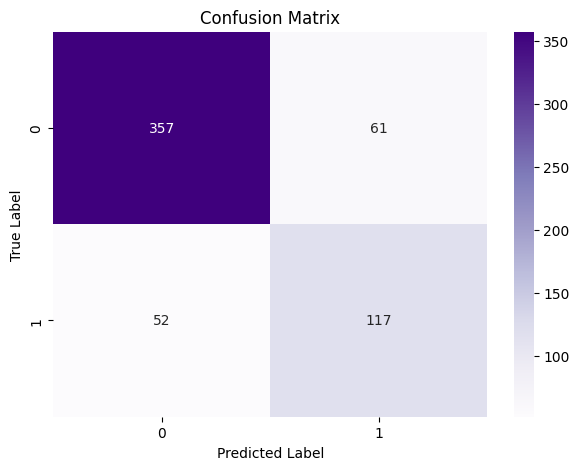

In [30]:
# Train an SVM on the combined representation
svc = svm.LinearSVC(class_weight = 'balanced', dual = False)
grid = GridSearchCV(estimator = svc, param_grid = param_grid, scoring = scoring, cv = cv, n_jobs = -1)

# Train the model
grid.fit(combined_bow_tr, labels_tr)

# Predict the labels
label_pred = grid.predict(combined_bow_val)

# Evaluate the model on the validation data.
print("\nClassification Report:\n", metrics.classification_report(labels_val, label_pred))

# Number of incorrect predictions.
incorrect_indices = [i for i, (real, pred) in enumerate(zip(labels_val, label_pred)) if real != pred]
print(f"\nNumber of incorrect predictions: {len(incorrect_indices)}\n")

# Confusion matrix.
cm = confusion_matrix(labels_val, label_pred)
plt.figure(figsize = (7,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', xticklabels = set(labels_val), yticklabels = set(labels_val))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### **4.2.- Hacer un experimento con las Bolsas de Emociones, Bolsa de Palabras y Bolsa de Bigramas; usted elige las dimensionalidades. Para construir la representación final del documento utilice la concatenación de las representaciones según sus observaciones (e.g., Bolsa de Palabras + Bolsa de Bigramas + Bolsa de Sentimientos de Canadá + Bolsa de Sentimientos de Grigori), y aliméntelas a un SVM.**

> Se usan:
>- BoW con 5000 palabras y pesado TF-IDF.
>- 1000 bigramas como en el ejercicio anterios.
>- BoE de EmoLex con pesado de frecuencia.
>- Boe de SEL con pesado de frecuencia
> Se concatenan y se aplica la clasificación SVM.


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86       418
           1       0.66      0.67      0.67       169

    accuracy                           0.81       587
   macro avg       0.76      0.77      0.76       587
weighted avg       0.81      0.81      0.81       587


Number of incorrect predictions: 114



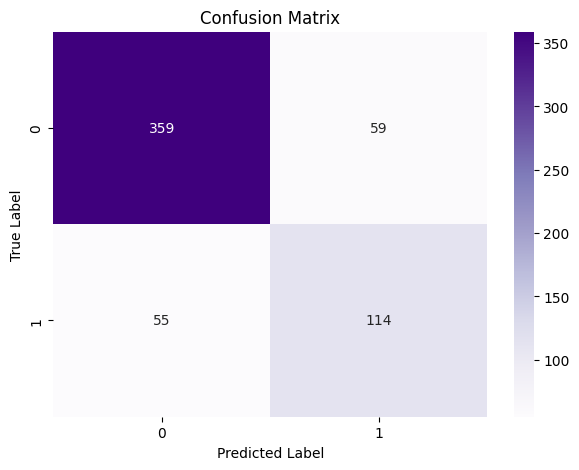

In [31]:
# BoW with 5000 words (TF-IDF)
word_tfidf_tr = build_bow_tfidf(data_tr, top_words, dict_indices)
word_tfidf_val = build_bow_tfidf(data_val, top_words, dict_indices)

# BoW with 1000 bigrams (Frequency)
bigram_bow_tr = build_bow_bigrams(data_tr, top_bigrams, bigram_indices)
bigram_bow_val = build_bow_bigrams(data_val, top_bigrams, bigram_indices)

# BoE with EmoLex (Frequency)
boe_emolex_tr = build_BoE_frequency(data_tr, emotions, emolex_dict, normalized=True)
boe_emolex_val = build_BoE_frequency(data_val, emotions, emolex_dict, normalized=True)

# BoE with SEL (Frequency)
boe_sel_tr = build_BoE_frequency(data_tr, emotions_list, sel_dict, normalized=True)
boe_sel_val = build_BoE_frequency(data_val, emotions_list, sel_dict, normalized=True)

# Concatenate all representations
final_rep_tr = np.hstack([word_tfidf_tr, bigram_bow_tr, boe_emolex_tr, boe_sel_tr])
final_rep_val = np.hstack([word_tfidf_val, bigram_bow_val, boe_emolex_val, boe_sel_val])

# Train an SVM on the combined representation
svc = svm.LinearSVC(class_weight = 'balanced', dual = False)
grid = GridSearchCV(estimator = svc, param_grid = param_grid, scoring = scoring, cv = cv, n_jobs = -1)

# Train the model
grid.fit(final_rep_tr, labels_tr)

# Predict the labels
label_pred = grid.predict(final_rep_val)

# Evaluate the model on the validation data.
print("\nClassification Report:\n", metrics.classification_report(labels_val, label_pred))

# Number of incorrect predictions.
incorrect_indices = [i for i, (real, pred) in enumerate(zip(labels_val, label_pred)) if real != pred]
print(f"\nNumber of incorrect predictions: {len(incorrect_indices)}\n")

# Confusion matrix.
cm = confusion_matrix(labels_val, label_pred)
plt.figure(figsize = (7,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', xticklabels = set(labels_val), yticklabels = set(labels_val))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### **4.3.- Elabore conclusiones sobre toda esta Tarea, incluyendo observaciones, comentarios y posibles mejoras futuras. Discuta el comportamiento de la BoW de usar solo palabras a integrar bigramas, y luego a integrar todo ¿ayudó? o ¿empeoró?. Discuta también brevemente el costo computacional de los experimentos ¿Valió la Pena tener todo?. Sea breve: todo en NO más de dos párrafos.**

>El experimento mostró que la combinación de diferentes representaciones mejora ligeramente la capacidad de clasificación del modelo. Usar solo BoW con palabras individuales (TF-IDF con 5000 palabras) obtuvo el mejor rendimiento inicial (F1 macro de 0.81, 96 errores para pesado TF-IDF). Al integrar bigramas, el desempeño fue similar (F1 macro de 0.77, 113 errores), lo que indica que la información adicional de las relaciones entre palabras no aportó una mejora significativa. Sin embargo, al agregar también Bolsas de Emociones (EmoLex y SEL), el rendimiento no mejoró y en algunos casos empeoró (F1 macro de 0.76-0.77, errores cercanos a 114). Esto sugiere que la información emocional no fue suficientemente discriminativa o que añadió ruido en la clasificación.
>
>En términos de costo computacional, cada nivel de integración incrementó significativamente la cantidad de características en el modelo, lo que aumenta el tiempo de cómputo y la complejidad del entrenamiento. La diferencia de rendimiento entre BoW con palabras individuales y la versión más completa con bigramas y emociones no justifica completamente el costo adicional. Una posible mejora sería explorar la selección de bigramas más relevantes en lugar de los más frecuentes, o probar técnicas como word embeddings para representar el significado de los textos de manera más efectiva.